##Install Dependencies

In [1]:
!pip install pandas numpy gensim==4.3.3 scikit-learn xgboost matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 11.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you hav

## Step 1: Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import re
import os
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# Create output folders
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

LABEL_NAMES = {0: 'negative', 1: 'neutral', 2: 'positive'}
LABEL_MAP_TEXT = {'negative': 0, 'neutral': 1, 'positive': 2}

---
## Step 2: Merge All Datasets

Make sure the `raw_data/` folder is in the same directory as this notebook with these files:
- `FinalTrainingOnly.tsv`
- `ValidationOnly.tsv`
- `FinalTest.tsv`
- `Ty.txt`
- `output.csv`

In [2]:
RAW = 'raw_data'

# Verify files exist
required = ['FinalTrainingOnly.tsv', 'ValidationOnly.tsv', 'FinalTest.tsv', 'Ty.txt', 'output.csv']
for fname in required:
    path = os.path.join(RAW, fname)
    if os.path.exists(path):
        print(f'  Found: {fname}')
    else:
        print(f'  MISSING: {fname}  <-- Please add this file to raw_data/ folder')

  MISSING: FinalTrainingOnly.tsv  <-- Please add this file to raw_data/ folder
  MISSING: ValidationOnly.tsv  <-- Please add this file to raw_data/ folder
  MISSING: FinalTest.tsv  <-- Please add this file to raw_data/ folder
  MISSING: Ty.txt  <-- Please add this file to raw_data/ folder
  MISSING: output.csv  <-- Please add this file to raw_data/ folder


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

os.chdir('/content/drive/MyDrive/hinglish-sentiment-analyzer')
print(os.getcwd())

/content/drive/MyDrive/hinglish-sentiment-analyzer


In [5]:
!ls -R

.:
data				   models    README.md	       src
Hinglish_Sentiment_Analyzer.ipynb  raw_data  requirements.txt

./data:
merged.csv

./models:
classifier.pkl	word2vec.model

./raw_data:
FinalTest.tsv  FinalTrainingOnly.tsv  output.csv  Ty.txt  ValidationOnly.tsv

./src:
app.py	merge_data.py  preprocess.py  train_classifier.py  train_word2vec.py


In [ ]:
!ls raw_data

In [6]:
import pandas as pd

df = pd.read_csv(
    "raw_data/FinalTrainingOnly.tsv",
    sep="\t"
)

df.head()

,3,pakistan ka ghra tauq pakistan israel ko tasleem nahein kerta isko palestin kehta - occupi palestin nan,0
0,41,madarchod mull ye mathura nahi dikha tha jab m...,0
1,48,manya pradhan mantri mahoday shriman narendra ...,2
2,64,krishna jcb full trend chal rahi aa nan,2
3,66,loksabha janta sirf modi ko vote de rahi thi n...,2
4,68,bhosdik tum pechvad ki tatti hi rahog bc nan,0


In [7]:
import pandas as pd

df = pd.read_csv(
    "raw_data/FinalTrainingOnly.tsv",
    sep="\t",
    header=None
)

print(df.shape)
print(df[2].value_counts())

(14594, 3)
2
1    5473
2    4869
0    4252
Name: count, dtype: int64


In [8]:
import os
import pandas as pd
# PATHS
RAW = "raw_data"
DATA = "data"
os.makedirs(DATA, exist_ok=True)
# LABEL MAP
LABEL_MAP_TEXT = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}
# TSV LOADER
def load_tsv(path):
    """
    Load TSV files of format:
    id \t text \t label
    """

    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")

            if len(parts) == 3:
                rows.append({
                    "id": parts[0],
                    "text": parts[1],
                    "label": int(parts[2])
                })

            elif len(parts) == 2:
                rows.append({
                    "id": parts[0],
                    "text": parts[1],
                    "label": None
                })

    return pd.DataFrame(rows)
# TRAINING DATA
train_df = load_tsv(
    os.path.join(RAW, "FinalTrainingOnly.tsv")
)

train_df = train_df[["text", "label"]]
train_df = train_df.dropna(subset=["label"])
train_df["label"] = train_df["label"].astype(int)

print(f"Training set: {len(train_df)} rows")

# VALIDATION DATA

val_df = load_tsv(
    os.path.join(RAW, "ValidationOnly.tsv")
)

val_df = val_df[["text", "label"]]
val_df = val_df.dropna(subset=["label"])
val_df["label"] = val_df["label"].astype(int)

print(f"Validation set: {len(val_df)} rows")

# TEST DATA + LABEL FILE
test_df = load_tsv(
    os.path.join(RAW, "FinalTest.tsv")
)

ty_labels = pd.read_csv(
    os.path.join(RAW, "Ty.txt")
)

ty_labels.columns = [
    c.strip() for c in ty_labels.columns
]

ty_labels["id"] = ty_labels["Uid"].astype(str)

ty_labels["label"] = (
    ty_labels["Sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(LABEL_MAP_TEXT)
)

test_df["id"] = test_df["id"].astype(str)

test_df = test_df.merge(
    ty_labels[["id", "label"]],
    on="id",
    how="inner"
)

# Fix: Select 'label_y' (from ty_labels) and rename it to 'label'
test_df = test_df[["text", "label_y"]]
test_df = test_df.rename(columns={"label_y": "label"})
test_df = test_df.dropna(subset=["label"])
test_df["label"] = test_df["label"].astype(int)

print(f"Test set: {len(test_df)} rows")

# OUTPUT.CSV
out_df = pd.read_csv(
    os.path.join(RAW, "output.csv")
)

out_df = out_df[["text", "label"]]
out_df = out_df.dropna()

out_df["label"] = out_df["label"].astype(int)

out_df["text"] = (
    out_df["text"]
    .astype(str)
    .str.strip()
)

print(f"output.csv: {len(out_df)} rows")

# MERGE ALL DATA
combined = pd.concat(
    [
        train_df,
        val_df,
        test_df,
        out_df
    ],
    ignore_index=True
)

combined["text_clean"] = (
    combined["text"]
    .astype(str)
    .str.strip()
    .str.lower()
)

before_dedup = len(combined)

combined = (
    combined
    .drop_duplicates(subset=["text_clean"])
    .drop(columns=["text_clean"])
)

after_dedup = len(combined)

print(f"Before dedup : {before_dedup}")
print(f"After dedup  : {after_dedup}")

# LABEL DISTRIBUTION
print("\nLabel Distribution:")
print(combined["label"].value_counts().sort_index())

# SAVE

output_path = os.path.join(DATA, "merged.csv")
combined.to_csv(
    output_path,
    index=False
)
print(f"\nSaved successfully to:")
print(output_path)
# PREVIEW
print("\nFirst 5 rows:")
print(combined.head())

Training set: 14594 rows
Validation set: 3000 rows
Test set: 2997 rows
output.csv: 2766 rows
Before dedup : 23357
After dedup  : 21369

Label Distribution:
label
0    5976
1    8210
2    7183
Name: count, dtype: int64

Saved successfully to:
data/merged.csv

First 5 rows:
                                                text  label
0  pakistan ka ghra tauq pakistan israel ko tasle...      0
1  madarchod mull ye mathura nahi dikha tha jab m...      0
2  manya pradhan mantri mahoday shriman narendra ...      2
3            krishna jcb full trend chal rahi aa nan      2
4  loksabha janta sirf modi ko vote de rahi thi n...      2


Label Distribution:
  Negative: 5976
   Neutral: 8210
  Positive: 7183


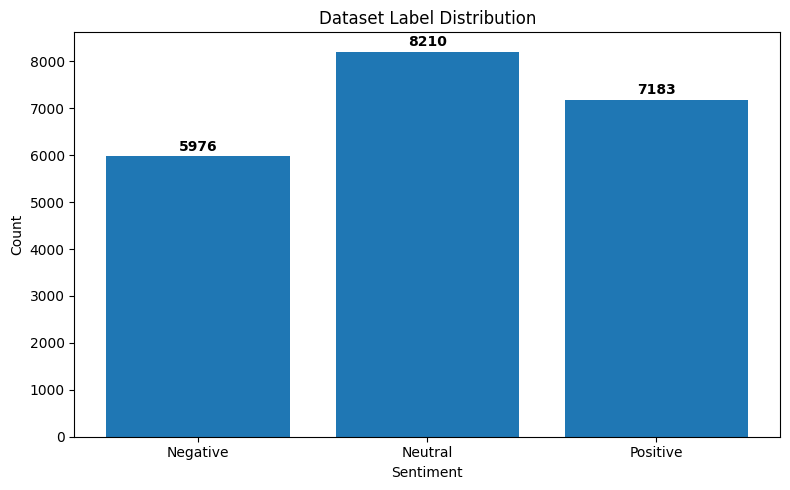

In [9]:
import matplotlib.pyplot as plt

# Label mapping
LABEL_NAMES = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

# Label Distribution

print("Label Distribution:")

counts = combined["label"].value_counts().sort_index()

for lbl in [0, 1, 2]:
    print(f"{LABEL_NAMES[lbl]:>10}: {counts.get(lbl, 0)}")

# Plot

plt.figure(figsize=(8, 5))

bars = plt.bar(
    [LABEL_NAMES[i] for i in counts.index],
    counts.values
)

plt.title("Dataset Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 50,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

---
## Step 3: Preprocessing

Custom Hinglish text preprocessing:
- Lowercasing, URL/mention removal
- **Spelling normalization** (nhi → nahi, bohot → bahut, accha → acha)
- Stopword removal & tokenization

In [10]:
import re

# SPELLING NORMALIZATION

NORMALIZE_MAP = {
    'nhi':'nahi', 'nahin':'nahi', 'nai':'nahi', 'ni':'nahi',
    'h':'hai', 'he':'hai',
    'thi':'tha',
    'kia':'kya', 'kiya':'kya',
    'bohot':'bahut', 'boht':'bahut', 'bhot':'bahut',
    'accha':'acha', 'achha':'acha', 'achchha':'acha', 'acchaa':'acha',
    'mazaa':'mast',
    'bakwaas':'bakwas', 'bakwass':'bakwas',
    'shi':'sahi',
    'bro':'bhai',
    'yar':'yaar',
    'thik':'theek', 'theik':'theek',
    'han':'haan', 'haa':'haan',
    'are':'arre', 'arey':'arre',
    'kuchh':'kuch', 'kuj':'kuch',
    'bilkl':'bilkul',
    'psand':'pasand',
    'jyada':'zyada', 'jada':'zyada',
    'bekaar':'bekar',
    'ghatia':'ghatiya',
    'wahiyaat':'wahiyat',
    'shandaar':'shandar',
    'lajawaab':'lajawab',
    'kamal':'kamaal',
    'paise':'paisa', 'pese':'paisa',
    'such':'sach'
}

# STOPWORDS

STOPWORDS = {
    'ka','ki','ke','ko','se','me','men','mai',
    'par','pe','ne','jo','ye','wo','is','us',
    'ek','aur','ya',

    'the','a','an','is','are','was','were',
    'be','been','being',
    'of','in','to','for','with',
    'on','at','by','it',
    'and','or','but','if','so',
    'as','that','this'
}

# CLEANING

def clean_text(text):

    text = str(text).lower().strip()

    # URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # mentions
    text = re.sub(r'@\w+', ' ', text)

    # hashtags
    text = re.sub(r'#(\w+)', r'\1', text)

    # remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)

    # remove digits
    text = re.sub(r'\d+', ' ', text)

    # compress repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# TOKENIZATION + NORMALIZATION

def preprocess(text, remove_stops=True):

    text = clean_text(text)

    tokens = text.split()

    # spelling normalization
    tokens = [NORMALIZE_MAP.get(tok, tok) for tok in tokens]

    # remove stopwords
    if remove_stops:
        tokens = [
            tok for tok in tokens
            if tok not in STOPWORDS and len(tok) > 1
        ]

    return tokens

# DEMO

demo_sentences = [
    "Yaar yeh movie bahut boring thi!",
    "Bhai kal ka match toh ekdum mast tha!",
    "Yeh product bilkul bakwaas hai, waste of money",
    "Bhooooot acchaaa movieeee thi!!!",
    "Modi ji ka speech bohot acha tha"
]

print("PREPROCESSING DEMO")

for s in demo_sentences:

    print(f"\nOriginal : {s}")

    print(
        f"Tokens   : {preprocess(s)}"
    )

PREPROCESSING DEMO

Original : Yaar yeh movie bahut boring thi!
Tokens   : ['yaar', 'yeh', 'movie', 'bahut', 'boring', 'tha']

Original : Bhai kal ka match toh ekdum mast tha!
Tokens   : ['bhai', 'kal', 'match', 'toh', 'ekdum', 'mast', 'tha']

Original : Yeh product bilkul bakwaas hai, waste of money
Tokens   : ['yeh', 'product', 'bilkul', 'bakwas', 'hai', 'waste', 'money']

Original : Bhooooot acchaaa movieeee thi!!!
Tokens   : ['bhoot', 'acha', 'moviee', 'tha']

Original : Modi ji ka speech bohot acha tha
Tokens   : ['modi', 'ji', 'speech', 'bahut', 'acha', 'tha']


---
## Step 4: Train Word2Vec Embeddings

We train **Skip-Gram Word2Vec** from scratch on our Hinglish corpus (since pretrained English models don't understand Hinglish).

Sentence embedding formula:

$$v_{sentence} = \frac{1}{N} \sum_{i=1}^{N} w_i$$

where $w_i \in \mathbb{R}^{100}$ is the Word2Vec embedding of the $i$-th token.

In [11]:
import pandas as pd
from collections import Counter

# LOAD DATA

df = pd.read_csv("data/merged.csv")

print(f"Loaded {len(df):,} sentences")

# TOKENIZATION
# Keep stopwords for Word2Vec context learning

all_sentences = [
    preprocess(text, remove_stops=False)
    for text in df["text"].astype(str)
]

# Remove empty sentences
all_sentences = [
    sent for sent in all_sentences
    if len(sent) > 0
]

print(f"Non-empty sentences : {len(all_sentences):,}")

# VOCABULARY

word_counter = Counter()

for sent in all_sentences:
    word_counter.update(sent)

vocab_size = len(word_counter)

print(f"Vocabulary size     : {vocab_size:,}")

# CORPUS STATISTICS

num_tokens = sum(word_counter.values())

avg_length = (
    sum(len(sent) for sent in all_sentences)
    / len(all_sentences)
)

print(f"Total tokens        : {num_tokens:,}")
print(f"Average length      : {avg_length:.2f} words")

# MOST COMMON WORDS

print("\nTop 20 Most Frequent Tokens")

for word, freq in word_counter.most_common(20):
    print(f"{word:<15} {freq}")

# SAMPLE TOKENIZED SENTENCES

print("\nSample Tokenized Sentences")

for i in range(5):
    print(all_sentences[i])

Loaded 21,369 sentences
Non-empty sentences : 21,367
Vocabulary size     : 38,187
Total tokens        : 325,928
Average length      : 15.25 words

Top 20 Most Frequent Tokens
hai             8455
nan             6327
ki              6202
nahi            5522
ke              4787
ko              4700
ka              3820
se              3221
aur             2934
ho              2370
bhi             2153
ye              2127
k               2094
hi              1903
ji              1798
kya             1581
ne              1496
jo              1437
hain            1406
men             1376

Sample Tokenized Sentences
['pakistan', 'ka', 'ghra', 'tauq', 'pakistan', 'israel', 'ko', 'tasleem', 'nahein', 'kerta', 'isko', 'palestin', 'kehta', 'occupi', 'palestin', 'nan']
['madarchod', 'mull', 'ye', 'mathura', 'nahi', 'dikha', 'tha', 'jab', 'mullo', 'ne', 'hindu', 'ko', 'iss', 'liy', 'mara', 'ki', 'vo', 'lass', 'ki', 'pais', 'mag', 'liy']
['manya', 'pradhan', 'mantri', 'mahoday', 'shriman', 'na

In [12]:
from gensim.models import Word2Vec
import os

os.makedirs("models", exist_ok=True)

# WORD2VEC PARAMETERS

VECTOR_SIZE = 100      # embedding dimension
WINDOW = 5             # context window
MIN_COUNT = 3          # remove very rare words
EPOCHS = 20            # sufficient for this corpus

print("Training Skip-Gram Word2Vec")

w2v_model = Word2Vec(
    sentences=all_sentences,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    sg=1,              # Skip-Gram
    negative=10,       # negative sampling
    workers=4,
    epochs=EPOCHS,
    seed=42
)

# SAVE MODEL

w2v_model.save("models/word2vec.model")

print("\nTraining Complete!")

print(f"Vocabulary Size : {len(w2v_model.wv):,}")
print(f"Vector Size     : {w2v_model.wv.vector_size}")

# QUICK TESTS

test_words = [
    "modi",
    "pakistan",
    "acha",
    "bakwas",
    "hindu",
    "muslim"
]

for word in test_words:

    if word in w2v_model.wv:

        print(f"\nMost similar to '{word}'")

        for w, score in w2v_model.wv.most_similar(word, topn=5):
            print(f"{w:15s} {score:.4f}")

Training Skip-Gram Word2Vec

Training Complete!
Vocabulary Size : 11,430
Vector Size     : 100

Most similar to 'modi'
narendra        0.7211
doobara         0.6683
narend          0.6448
sapath          0.6431
manniy          0.6420

Most similar to 'pakistan'
nei             0.5753
jeetay          0.5682
phook           0.5646
iccricketworldcup 0.5552
nizam           0.5517

Most similar to 'acha'
atankwad        0.5913
bnayi           0.5675
huma            0.5531
hanumansingh    0.5515
dukandar        0.5448

Most similar to 'hindu'
muslim          0.7567
musalman        0.6548
kattar          0.6370
khatr           0.6064
manat           0.5755

Most similar to 'muslim'
hindu           0.7567
proxi           0.5953
religion        0.5763
secular         0.5560
musalmaano      0.5552


In [13]:
# Sanity check — similar words
print('Word Similarity Check:')
test_words = ['acha', 'bakwas', 'mast', 'bekar', 'shandar', 'ghatiya']
for w in test_words:
    if w in w2v_model.wv:
        similar = w2v_model.wv.most_similar(w, topn=5)
        print(f"  '{w}' is similar to: {[s[0] for s in similar]}")
    else:
        print(f"  '{w}' not found in vocabulary")

Word Similarity Check:
  'acha' is similar to: ['atankwad', 'bnayi', 'huma', 'hanumansingh', 'dukandar']
  'bakwas' not found in vocabulary
  'mast' is similar to: ['dkhte', 'terko', 'bahat', 'raval', 'viral']
  'bekar' is similar to: ['dikhata', 'kma', 'aakhir', 'koie', 'pde']
  'shandar' is similar to: ['gurjar', 'evam', 'haardik', 'prachand', 'dhero']
  'ghatiya' is similar to: ['besharm', 'intehai', 'enko', 'maansikta', 'jese']


---
## Step 5: Build Feature Matrix (Avg-Word2Vec)

Convert each sentence into a **fixed-size 100-dimensional vector** by averaging all its token embeddings.

In [14]:
import numpy as np

# SENTENCE EMBEDDING FUNCTION

def sentence_vector(tokens, model):
    """
    Convert a tokenized sentence into a fixed-length vector
    by averaging Word2Vec embeddings.
    """

    vectors = [
        model.wv[token]
        for token in tokens
        if token in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

# PREPROCESS FOR CLASSIFICATION
# Remove stopwords here

tokens_list = [
    preprocess(text, remove_stops=True)
    for text in df["text"].astype(str)
]

# CREATE FEATURE MATRIX

X = np.array([
    sentence_vector(tokens, w2v_model)
    for tokens in tokens_list
])

y = df["label"].values

# DATASET INFORMATION

print("FEATURE EXTRACTION COMPLETE")

print(f"Feature Matrix Shape : {X.shape}")
print(f"Label Vector Shape   : {y.shape}")

print("\nClasses:")

unique, counts = np.unique(y, return_counts=True)

label_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

for cls, cnt in zip(unique, counts):
    print(
        f"{label_names[cls]:<10}: "
        f"{cnt}"
    )

# SAMPLE VECTOR

print("\nSample Sentence:")

print(df.iloc[0]["text"])

print("\nFirst 10 dimensions of embedding:")

print(X[0][:10])

# CHECK FOR ZERO VECTORS

zero_vectors = np.sum(
    np.all(X == 0, axis=1)
)

print(
    f"\nSentences with zero embeddings: "
    f"{zero_vectors}"
)

FEATURE EXTRACTION COMPLETE
Feature Matrix Shape : (21369, 100)
Label Vector Shape   : (21369,)

Classes:
Negative  : 5976
Neutral   : 8210
Positive  : 7183

Sample Sentence:
pakistan ka ghra tauq pakistan israel ko tasleem nahein kerta isko palestin kehta - occupi palestin nan

First 10 dimensions of embedding:
[-0.00434835  0.06629597 -0.12890533  0.45956594 -0.28115541  0.05879505
  0.01849067  0.62987345  0.18771859  0.01386884]

Sentences with zero embeddings: 15


In [15]:
from sklearn.model_selection import train_test_split
import pandas as pd

# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("TRAIN-TEST SPLIT")

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")

# CLASS DISTRIBUTION CHECK

label_names = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

train_dist = pd.Series(y_train).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

print("\nTraining Distribution")

for cls in train_dist.index:
    pct = 100 * train_dist[cls] / len(y_train)
    print(
        f"{label_names[cls]:<10} : "
        f"{train_dist[cls]:5d} "
        f"({pct:.2f}%)"
    )

print("\nTesting Distribution")

for cls in test_dist.index:
    pct = 100 * test_dist[cls] / len(y_test)
    print(
        f"{label_names[cls]:<10} : "
        f"{test_dist[cls]:5d} "
        f"({pct:.2f}%)"
    )

# SHAPES

print("\nFeature Matrix Shapes")

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

TRAIN-TEST SPLIT
Training samples : 17,095
Testing samples  : 4,274

Training Distribution
Negative   :  4781 (27.97%)
Neutral    :  6568 (38.42%)
Positive   :  5746 (33.61%)

Testing Distribution
Negative   :  1195 (27.96%)
Neutral    :  1642 (38.42%)
Positive   :  1437 (33.62%)

Feature Matrix Shapes
X_train : (17095, 100)
X_test  : (4274, 100)
y_train : (17095,)
y_test  : (4274,)


---
## Step 6: Train Classifiers

We train two models and compare:
1. **SVM** (Linear kernel)
2. **XGBoost**

### 6a. SVM

In [16]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TRAINING LINEAR SVM")

# MODEL

svm_base = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

# Probability calibration
svm_model = CalibratedClassifierCV(
    svm_base,
    cv=3
)

# TRAIN

svm_model.fit(X_train, y_train)

# PREDICT

y_pred_svm = svm_model.predict(X_test)

# METRICS

svm_acc = accuracy_score(
    y_test,
    y_pred_svm
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    average="macro"
)

print(f"\nAccuracy : {svm_acc:.4f}")
print(f"Macro F1 : {svm_f1:.4f}")

# CLASSIFICATION REPORT

LABEL_NAMES = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            LABEL_NAMES[0],
            LABEL_NAMES[1],
            LABEL_NAMES[2]
        ]
    )
)

# CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    y_pred_svm
)

print("\nConfusion Matrix")

print(cm)

TRAINING LINEAR SVM

Accuracy : 0.5990
Macro F1 : 0.6032

Classification Report
              precision    recall  f1-score   support

    Negative       0.64      0.59      0.61      1195
     Neutral       0.53      0.55      0.54      1642
    Positive       0.65      0.66      0.65      1437

    accuracy                           0.60      4274
   macro avg       0.61      0.60      0.60      4274
weighted avg       0.60      0.60      0.60      4274


Confusion Matrix
[[707 403  85]
 [315 908 419]
 [ 85 407 945]]


### 6b. XGBoost

In [17]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TRAINING XGBOOST")

# MODEL

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# TRAIN

xgb_model.fit(
    X_train,
    y_train
)

# PREDICT

y_pred_xgb = xgb_model.predict(
    X_test
)

# METRICS

xgb_acc = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average="macro"
)

print(f"\nAccuracy : {xgb_acc:.4f}")
print(f"Macro F1 : {xgb_f1:.4f}")

# CLASSIFICATION REPORT

LABEL_NAMES = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

print("\nClassification Report")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=[
            LABEL_NAMES[0],
            LABEL_NAMES[1],
            LABEL_NAMES[2]
        ]
    )
)

# CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

print("\nConfusion Matrix")

print(cm)

# MODEL COMPARISON

print("\nModel Comparison")

try:
    print(f"SVM Macro F1 : {svm_f1:.4f}")
except:
    print("SVM score not available")

print(f"XGB Macro F1 : {xgb_f1:.4f}")

TRAINING XGBOOST

Accuracy : 0.6390
Macro F1 : 0.6424

Classification Report
              precision    recall  f1-score   support

    Negative       0.67      0.64      0.65      1195
     Neutral       0.58      0.59      0.58      1642
    Positive       0.68      0.70      0.69      1437

    accuracy                           0.64      4274
   macro avg       0.64      0.64      0.64      4274
weighted avg       0.64      0.64      0.64      4274


Confusion Matrix
[[ 762  342   91]
 [ 303  963  376]
 [  76  355 1006]]

Model Comparison
SVM Macro F1 : 0.6032
XGB Macro F1 : 0.6424


---
## Step 7: Evaluation & Comparison

In [18]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Linear SVM", "XGBoost"],
    "Macro F1": [svm_f1, xgb_f1]
})

comparison_df

,Model,Macro F1
0,Linear SVM,0.603203
1,XGBoost,0.642363


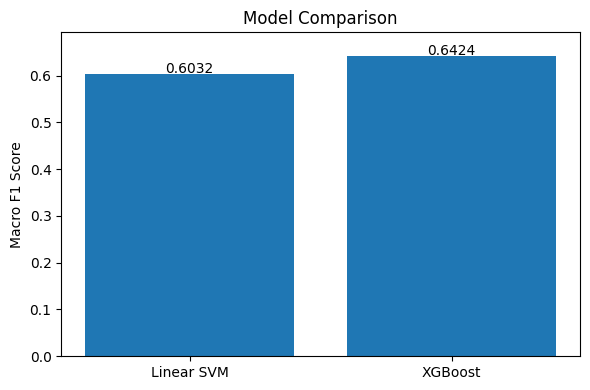

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Macro F1"]
)

plt.title("Model Comparison")
plt.ylabel("Macro F1 Score")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.4f}",
        ha="center"
    )

plt.ylim(
    0,
    max(comparison_df["Macro F1"]) + 0.05
)

plt.tight_layout()
plt.show()

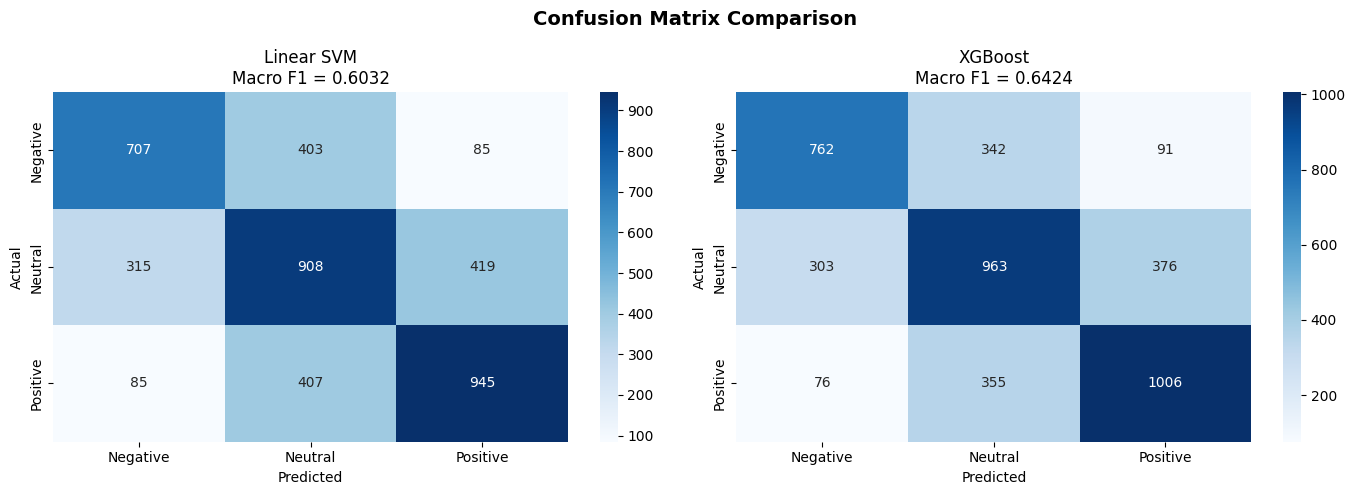

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

LABEL_NAMES = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

models = [
    ("Linear SVM", y_pred_svm, svm_f1),
    ("XGBoost", y_pred_xgb, xgb_f1)
]

for ax, (name, preds, f1) in zip(axes, models):

    cm = confusion_matrix(
        y_test,
        preds
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=list(LABEL_NAMES.values()),
        yticklabels=list(LABEL_NAMES.values())
    )

    ax.set_title(
        f"{name}\nMacro F1 = {f1:.4f}"
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle(
    "Confusion Matrix Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [21]:
import pickle
import os

os.makedirs("models", exist_ok=True)

# SELECT BEST MODEL

if xgb_f1 >= svm_f1:

    best_model = xgb_model
    best_label = "xgboost"
    best_score = xgb_f1

else:

    best_model = svm_model
    best_label = "svm"
    best_score = svm_f1

print(f"BEST MODEL: {best_label.upper()}")
print(f"MACRO F1 : {best_score:.4f}")

# RETRAIN ON FULL DATASET

print(f"\nRetraining {best_label.upper()} on full dataset...")

best_model.fit(
    X,
    y
)

print("Training complete.")

# SAVE EVERYTHING

model_package = {

    "classifier": best_model,

    "classifier_name": best_label,

    "vector_size": VECTOR_SIZE,

    "label_map": {
        0: "Negative",
        1: "Neutral",
        2: "Positive"
    }

}

save_path = "models/classifier.pkl"

with open(save_path, "wb") as f:

    pickle.dump(
        model_package,
        f
    )

print(f"\nSaved to: {save_path}")

# VERIFY SAVE

with open(save_path, "rb") as f:

    loaded = pickle.load(f)

print("\nVerification")

print(
    f"Classifier: "
    f"{loaded['classifier_name']}"
)

print(
    f"Vector Size: "
    f"{loaded['vector_size']}"
)

print(
    f"Labels: "
    f"{loaded['label_map']}"
)

BEST MODEL: XGBOOST
MACRO F1 : 0.6424

Retraining XGBOOST on full dataset...
Training complete.

Saved to: models/classifier.pkl

Verification
Classifier: xgboost
Vector Size: 100
Labels: {0: 'Negative', 1: 'Neutral', 2: 'Positive'}


---
## Step 8: Live Prediction Demo

The pipeline is complete! Let's test it on some Hinglish sentences.

In [ ]:
# SENTIMENT PREDICTION FUNCTION

def predict_sentiment(text):

    # Preprocess text
    tokens = preprocess(text)

    # Convert to sentence embedding
    vec = sentence_vector(
        tokens,
        w2v_model
    ).reshape(1, -1)

    # Prediction
    pred_class = best_model.predict(vec)[0]

    # Probabilities
    if hasattr(best_model, "predict_proba"):

        probs = best_model.predict_proba(vec)[0]

        confidence = (
            probs[pred_class] * 100
        )

        prob_dict = {
            LABEL_NAMES[i]:
            round(probs[i] * 100, 2)
            for i in range(3)
        }

    else:

        confidence = None

        prob_dict = {
            LABEL_NAMES[i]: None
            for i in range(3)
        }

    return (
        LABEL_NAMES[pred_class],
        confidence,
        prob_dict
    )

# DEMO PREDICTIONS

test_sentences = [
    "Yaar yeh movie bahut boring thi!",
    "Bhai kal ka match toh ekdum mast tha!",
    "Theek hi tha, kuch khaas nahi",
    "Yeh product bilkul bakwaas hai, waste of money",
    "Bohot accha experience tha, definitely recommend karunga",
    "Mujhe koi fark nahi padta",
    "Modi ji ka speech bahut acha tha",
    "Pakistan ki team aaj bahut kharab kheli"
]

print(f"MODEL : {best_label.upper()}")

for sentence in test_sentences:

    label, confidence, probs = predict_sentiment(
        sentence
    )

    print(f"Input      : {sentence}")

    print(f"Prediction : {label}")

    if confidence is not None:

        print(
            f"Confidence : "
            f"{confidence:.2f}%"
        )

        print(
            f"Probabilities : "
            f"{probs}"
        )

In [ ]:
# INTERACTIVE PREDICTION

your_text = input("Enter a Hinglish sentence: ")

if len(your_text.strip()) > 0:

    label, conf, probs = predict_sentiment(
        your_text
    )

    print(f"Input      : {your_text}")

    print(f"Sentiment  : {label}")

    print(f"Confidence : {conf:.2f}%")

    print("\nClass Probabilities")

    for sentiment, score in probs.items():

        print(
            f"{sentiment:<10} "
            f"{score:>6.2f}%"
        )

else:

    print("No text entered.")